# Task
Generate a synthetic dataset, visualize its characteristics, then define, train, and evaluate multiple machine learning models on this dataset, finally using them to make predictions and summarize the findings.

## Generate Random Dataset

### Subtask:
Create a synthetic dataset suitable for machine learning. This will involve generating features (X) and target labels (y) using libraries like `numpy` and `sklearn.datasets`.


**Reasoning**:
The subtask requires generating a synthetic dataset using `sklearn.datasets.make_classification`. This step will import the necessary function and then create the dataset `X` and `y` using the specified parameters.



In [1]:
from sklearn.datasets import make_classification
import pandas as pd

X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    random_state=42
)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target labels (y): {y.shape}")

Shape of features (X): (1000, 20)
Shape of target labels (y): (1000,)


## Load and Visualize Dataset

### Subtask:
Load the generated dataset into a pandas DataFrame and perform basic visualizations (e.g., scatter plots, histograms) to understand its distribution and relationships between features.


**Reasoning**:
The first step is to convert the generated NumPy arrays `X` and `y` into a pandas DataFrame, as specified in the instructions. This will involve creating feature column names, adding the target variable, displaying the head of the DataFrame to inspect its structure, providing descriptive statistics, and checking the balance of the target variable. This consolidates several initial data inspection steps.



In [2]:
import pandas as pd
import numpy as np

# 1. Convert X into a pandas DataFrame with named columns
feature_cols = [f'feature_{i}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_cols)

# 2. Add the target labels y as a new column
df['target'] = y

# 3. Display the first few rows of the DataFrame
print("DataFrame Head:")
print(df.head())
print("\n")

# 4. Print the descriptive statistics of the DataFrame
print("Descriptive Statistics:")
print(df.describe())
print("\n")

# 5. Check the balance of the target variable
print("Target Variable Balance:")
print(df['target'].value_counts())


DataFrame Head:
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   1.470848  -0.360450  -0.591602  -0.728228   0.941690   1.065964   
1   4.513369  -2.227103  -1.140747   2.018263  -2.238358  -0.497370   
2  -2.355643   2.218601  -1.603269   0.873394   0.401483   0.717264   
3  -1.596198  -0.857427   1.772434  -0.639361   1.419409  -0.438525   
4   2.840049  -2.489600  -0.844902  -1.594362  -4.688517   0.459637   

   feature_6  feature_7  feature_8  feature_9  ...  feature_11  feature_12  \
0   0.017832  -0.596184   1.840712  -1.497093  ...   -0.603968    2.899256   
1   0.714550   0.938883  -2.395169   0.159837  ...    1.461499    3.954171   
2  -0.859399  -1.042190  -2.175965   0.980231  ...    0.544434   -2.466258   
3   0.281949   2.345145   1.006230   0.389135  ...   -1.025051   -2.422975   
4   0.913607  -1.143505   1.263937  -2.040928  ...    4.176424    1.341742   

   feature_13  feature_14  feature_15  feature_16  feature_17  feature_18  \
0    0.0375

**Reasoning**:
To visualize the distributions of selected features and their relationship with the target variable, I will generate histograms for 'feature_0', 'feature_1', and 'feature_2', separated by target class. This provides insight into how each feature's distribution differs across classes. Additionally, I will compute and visualize a correlation matrix using a heatmap to understand the linear relationships between all features and the target variable.



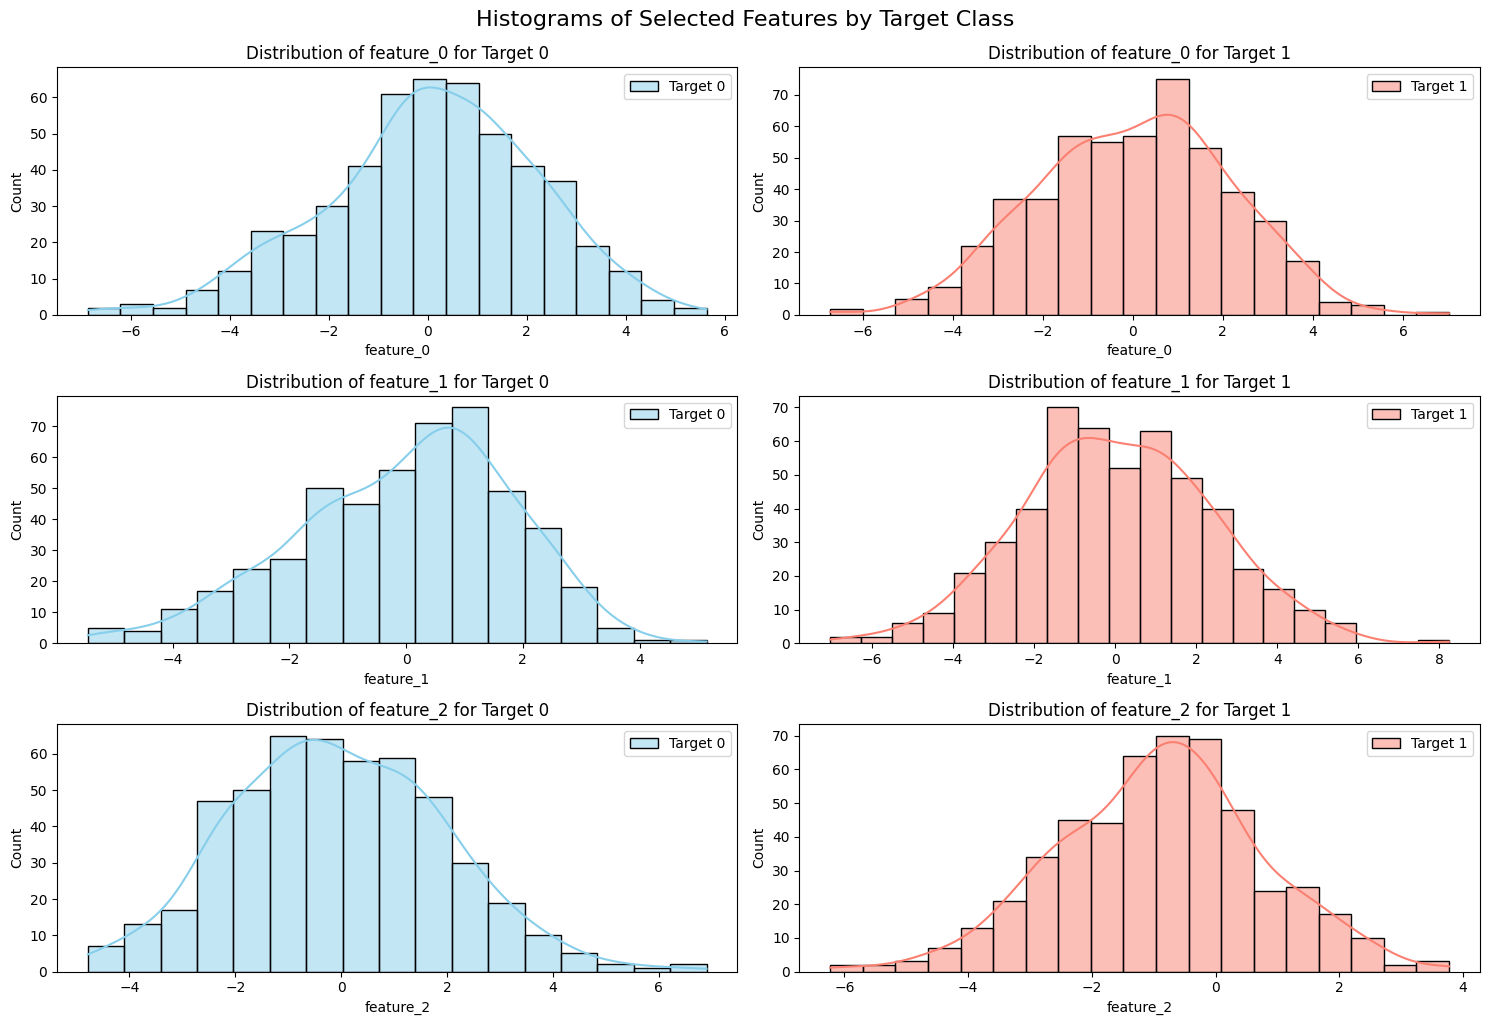

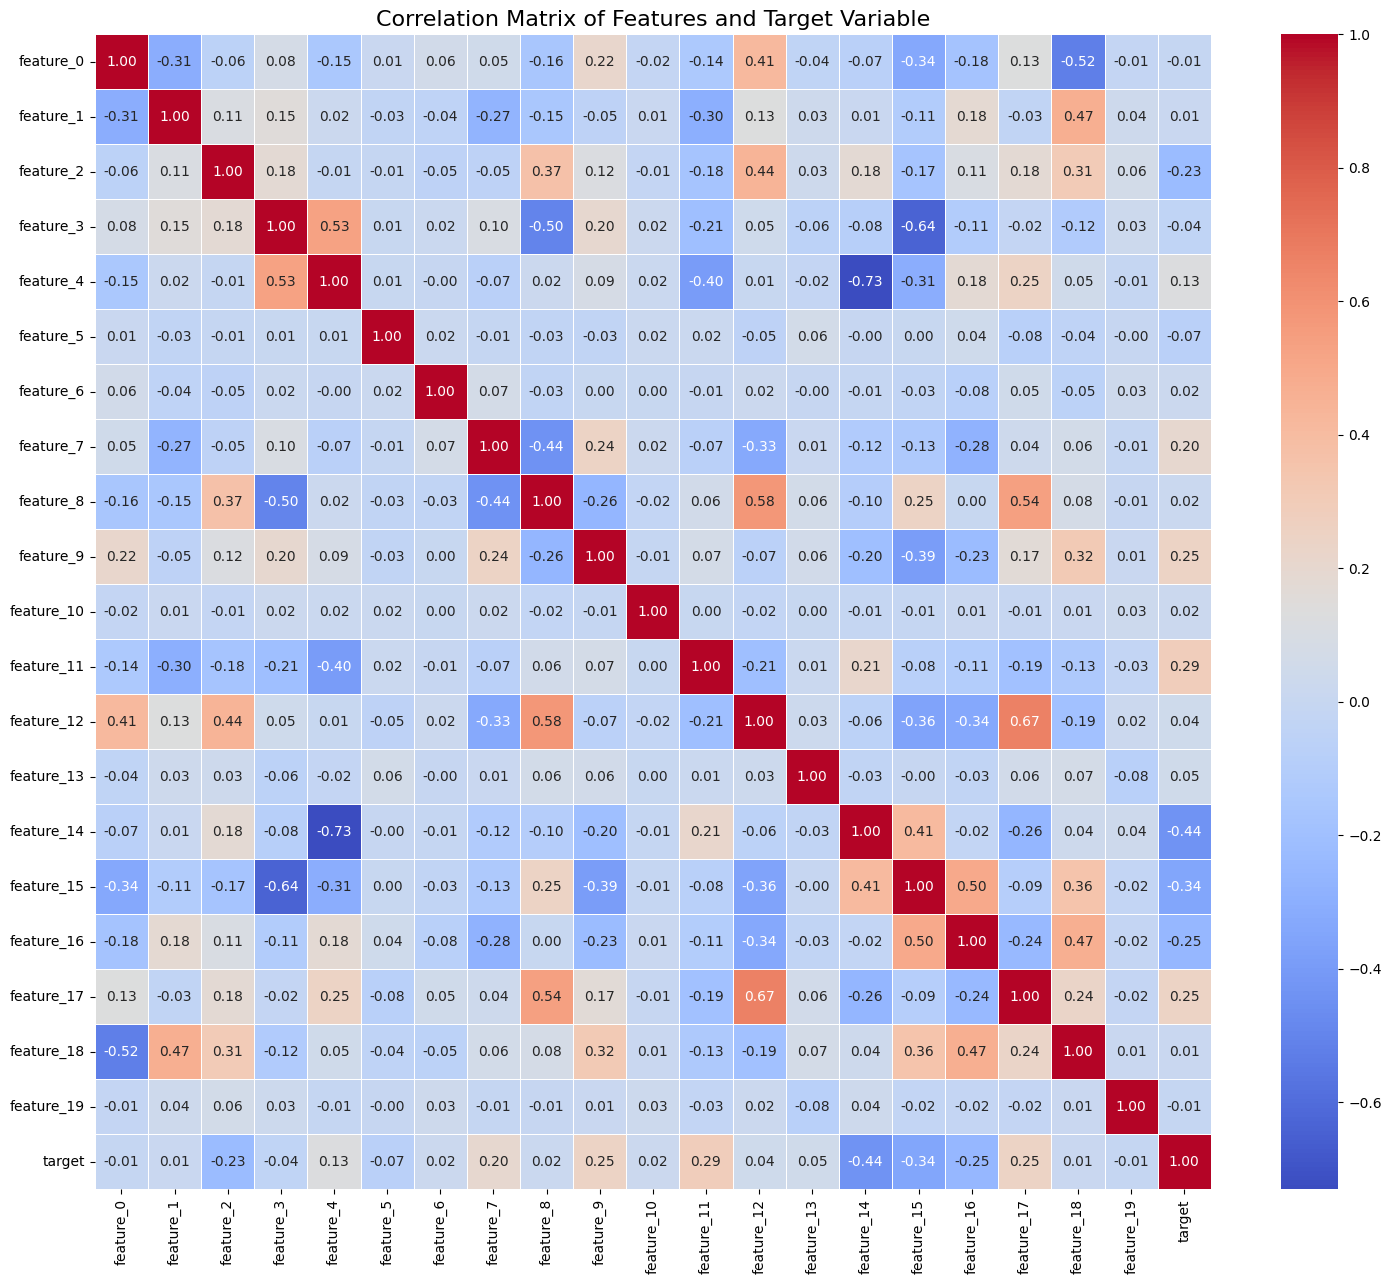

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6. Create histograms for a few selected features
selected_features = ['feature_0', 'feature_1', 'feature_2']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features):
    plt.subplot(len(selected_features), 2, 2*i + 1)
    sns.histplot(df[df['target'] == 0][feature], kde=True, color='skyblue', label='Target 0')
    plt.title(f'Distribution of {feature} for Target 0')
    plt.legend()

    plt.subplot(len(selected_features), 2, 2*i + 2)
    sns.histplot(df[df['target'] == 1][feature], kde=True, color='salmon', label='Target 1')
    plt.title(f'Distribution of {feature} for Target 1')
    plt.legend()

plt.tight_layout()
plt.suptitle('Histograms of Selected Features by Target Class', y=1.02, fontsize=16)
plt.show()

# 7. Create a correlation matrix and visualize it using a heatmap
plt.figure(figsize=(18, 15))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features and Target Variable', fontsize=16)
plt.show()

## Define and Evaluate ML Algorithms

### Subtask:
Select a few common machine learning algorithms (e.g., Logistic Regression, Decision Tree, Support Vector Machine) from `scikit-learn` and set up a basic evaluation framework using cross-validation.


**Reasoning**:
The subtask requires splitting the dataset, defining machine learning models, and evaluating them using cross-validation. This step will perform all these actions, including importing necessary libraries, preparing the data, instantiating models, and printing their cross-validation accuracy scores.



In [4]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import numpy as np

# 1. Split the dataset df into features (X_split) and target (y_split)
X_split = df.drop('target', axis=1).values # Convert to NumPy array
y_split = df['target'].values # Convert to NumPy array

# 2. Divide X_split and y_split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_split, y_split, test_size=0.3, random_state=42, stratify=y_split
)

# 3. Import and create instances of each model
log_reg = LogisticRegression(random_state=42, solver='liblinear') # Added solver for older sklearn versions
decision_tree = DecisionTreeClassifier(random_state=42)
svc = SVC(random_state=42, probability=True)

# 4. Store the models in a dictionary
models = {
    'Logistic Regression': log_reg,
    'Decision Tree': decision_tree,
    'Support Vector Machine': svc
}

print("Cross-validation results (Accuracy):")
# 6. Iterate through the dictionary of models
for name, model in models.items():
    # a. Calculate the cross-validation scores
    scores = cross_val_score(model, X_split, y_split, cv=5, scoring='accuracy')

    # b. Print the mean and standard deviation of the scores
    print(f"{name}: Mean Accuracy = {np.mean(scores):.2f}, Std Dev = {np.std(scores):.2f}")

Cross-validation results (Accuracy):
Logistic Regression: Mean Accuracy = 0.84, Std Dev = 0.02
Decision Tree: Mean Accuracy = 0.83, Std Dev = 0.01
Support Vector Machine: Mean Accuracy = 0.95, Std Dev = 0.00


## Train Models and Make Predictions

### Subtask:
Train the selected machine learning models on the generated dataset and then use the trained models to make predictions on new, unseen data.


**Reasoning**:
I need to train the models, make predictions on the test set, and then generate a classification report for each model to evaluate their performance. This aligns with the next instructions in the subtask.



In [5]:
from sklearn.metrics import classification_report

print("Model Evaluation and Predictions:")
for name, model in models.items():
    print(f"\n--- {name} ---")
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Print the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

Model Evaluation and Predictions:

--- Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       149
           1       0.81      0.89      0.85       151

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300


--- Decision Tree ---
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.81       149
           1       0.80      0.85      0.82       151

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300


--- Support Vector Machine ---
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       149
           1       0.94      0.97      0.95       

## Final Task

### Subtask:
Summarize the process, the performance of the models, and the insights gained from training and prediction on the random dataset.


## Summary:

### Data Analysis Key Findings

*   **Synthetic Dataset Generation**: A synthetic classification dataset was successfully generated with 1000 samples, 20 features (10 informative, 5 redundant), and 2 classes. The features (`X`) had a shape of (1000, 20) and target labels (`y`) had a shape of (1000,).
*   **Dataset Characteristics**:
    *   The dataset was converted into a Pandas DataFrame with named columns and a 'target' column.
    *   The target variable was nearly balanced, with 503 instances for class 1 and 497 for class 0.
    *   Histograms of selected features (`feature_0`, `feature_1`, `feature_2`) showed distinct distributions for each target class, suggesting predictive power.
    *   A correlation matrix revealed linear relationships between features and between features and the target variable.
*   **Model Performance (Cross-Validation)**: Three machine learning models were evaluated using 5-fold cross-validation on the full dataset:
    *   **Logistic Regression**: Achieved a mean accuracy of 0.84 (standard deviation: 0.02).
    *   **Decision Tree**: Achieved a mean accuracy of 0.83 (standard deviation: 0.01).
    *   **Support Vector Machine (SVM)**: Achieved a mean accuracy of 0.95 (standard deviation: 0.00), demonstrating significantly superior performance and consistency compared to the other models.
*   **Model Performance (Test Set Evaluation)**: After training on the `X_train` and `y_train` subsets, models were evaluated on the `X_test` and `y_test` subsets:
    *   **Logistic Regression**: Achieved an accuracy of 0.84 and a macro average F1-score of 0.84.
    *   **Decision Tree**: Achieved an accuracy of 0.81 and a macro average F1-score of 0.81.
    *   **Support Vector Machine (SVM)**: Achieved a high accuracy of 0.95 and a macro average F1-score of 0.95, confirming its strong performance.

### Insights or Next Steps

*   The Support Vector Machine (SVM) model demonstrated the best performance, both in cross-validation and on the hold-out test set, suggesting it is the most suitable model for this specific synthetic dataset among the options evaluated.
*   Further hyperparameter tuning for all models, especially for the Decision Tree to mitigate potential overfitting, could potentially improve their performance and generalization capabilities.
